### **Анализ одноканальной системы с отказами**

**Цель работы:**

Исследовать характеристики одноканальной системы массового обслуживания с отказами (M/M/1/0) с использованием методов имитационного моделирования.


### **Задачи:**

1. Разработать имитационную модель одноканальной системы с отказами.
2. Провести эксперименты с различными параметрами системы.
3. Проанализировать полученные результаты и сделать выводы.


### **Исходные данные:**

- Интенсивность входящего потока заявок (λ): задается вариантом (например, 5 заявок/час).
- Интенсивность обслуживания (μ): задается вариантом (например, 6 заявок/час).
- Время моделирования: 1000 единиц времени (часы, минуты и т.д., в зависимости от контекста).

### _**Шаги выполнения работы:**_

_1. **Разработка модели:**_
- _Создайте имитационную модель одноканальной системы с отказами._
- _Учтите, что если заявка поступает в момент, когда канал занят, она теряется._
- _Используйте генератор случайных чисел для моделирования входящего потока и времени обслуживания._

Выбранная СМО - окно МФЦ, время моделирования будет измеряться в минутах.

In [10]:
from cProfile import label

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd
from tensorboard.notebook import display

np.random.seed(42)

SERVICE_RATE = 6  # мю - интенсивность облуживания, посетителей/час
SIMULATION_TIME = 1000  # продолжительность симуляции, часов
# ARRIVAL_RATE (lambda) будет изменяться

2. ***Проведение экспериментов:***
- *Запустите модель для заданных значений λ и μ.*
- *Зафиксируйте следующие показатели:*
- *Количество поступивших заявок.*
- *Количество обслуженных заявок.*
- *Количество потерянных заявок.*
- *Вероятность отказа (доля потерянных заявок).*
- *Коэффициент загрузки системы (доля времени, когда канал занят).*

М/М/1/0 - значит система с пуассоновским распределением входящего потока (посетители приходят независимо, по одиночке и с одинаковой
интенсивностью), с экспоненциальным временем обслуживания, одноканальная, без очереди, - нотация Кендалла

на этом этапе работа системы будет выглядеть так:
1. посетитель приходит
2. если окно свободно - начинается обслуживание
3. если нет, то он уходит
4. обслуживание заканчивается, окно освобождается

будем использовать событийное моделирование

In [8]:
def simulate(arrival_rate, service_rate, simulation_time):
    total_arrived = 0
    total_served = 0
    total_rejected = 0
    busy_time = 0

    server_free_at = 0
    # время до прихода первого посетителя.
    # exponential принимает 1/intensity и строит экспоненциальное распределение.
    # то есть здесь - среднее время между пользователями в часах
    current_time = np.random.exponential(1 / arrival_rate)

    while current_time < simulation_time:
        total_arrived += 1

        # окно свободно
        if current_time >= server_free_at:
            total_served += 1
            service_duration = np.random.exponential(1 / service_rate)
            busy_time += service_duration
            server_free_at = current_time + service_duration

        # занято
        else:
            total_rejected += 1

        current_time += np.random.exponential(1 / arrival_rate)

    return {
        "arrived": total_arrived,
        "served": total_served,
        "rejected": total_rejected,
        "rejection_rate": round(total_rejected / total_arrived, 4),
        "utilization": round(busy_time / simulation_time, 4)  # доля времени, когда система занята, потребление
    }

3. ***Анализ результатов:***
- *Сравните полученные экспериментальные значения с теоретическими расчетами (используйте формулу Эрланга для вероятности отказа).*
- *Постройте графики зависимости вероятности отказа от интенсивности входящего потока (λ) при фиксированном μ.*
- *Сделайте выводы о влиянии параметров λ и μ на характеристики системы.*

запустим симуляцию на разных значениях интенсивности входящего потока и посмотрим на график

,"интенсивность, λ (чел/час)",поступило,обслужено,отказов,доля отказов,загрузка канала
0,1,1076,891,185,0.1719,0.1516
1,2,2002,1524,478,0.2388,0.2540
2,3,2963,2009,954,0.3220,0.3292
3,4,3990,2392,1598,0.4005,0.4101
4,5,4986,2757,2229,0.4471,0.4549
5,6,6171,3044,3127,0.5067,0.5147
6,7,7017,3232,3785,0.5394,0.5424
7,8,7973,3460,4513,0.5660,0.5680
8,9,9037,3597,5440,0.6020,0.6066
9,10,10139,3778,6361,0.6274,0.6286


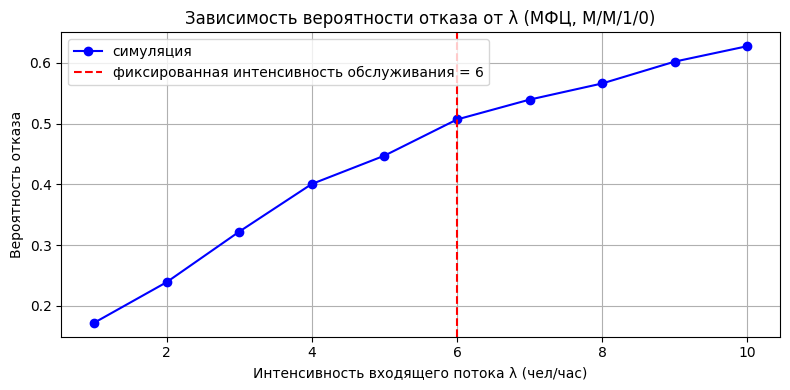

In [17]:
results = []
for arrival_rate in range(1, 11):
    simulation = simulate(arrival_rate, SERVICE_RATE, SIMULATION_TIME)
    results.append({
        "интенсивность, λ (чел/час)": arrival_rate,
        "поступило": simulation["arrived"],
        "обслужено": simulation["served"],
        "отказов": simulation["rejected"],
        "доля отказов": round(simulation["rejection_rate"], 4),
        "загрузка канала": round(simulation["utilization"], 4)
    })

df = pd.DataFrame(results)
display(df)

plt.style.use("default")
plt.figure(figsize=(8, 4))
plt.plot(
    df["интенсивность, λ (чел/час)"],
    df["доля отказов"],
    marker="o",
    color="blue",
    label="симуляция"
)

plt.axvline(
    x=SERVICE_RATE,
    color="red",
    linestyle="--",
    label=f"фиксированная интенсивность обслуживания = {SERVICE_RATE}"
)

plt.xlabel("Интенсивность входящего потока λ (чел/час)")
plt.ylabel("Вероятность отказа")
plt.title("Зависимость вероятности отказа от λ (МФЦ, M/M/1/0)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

вспомним теорию
### теоретические расчеты:

нагрузка системы:
$$\rho=\frac{\lambda}{\mu}$$

формула Эрланга для вероятности отказа:
$$P_{r} = \frac{\rho}{1 + \rho}$$

вероятность обслуживания:
$$P_{s} = 1 - P_r$$

коэффициент загрузки канала:
$$K_u = \rho * P_s$$

пропускная способность:
$$A = \lambda * P_s = \frac{\lambda}{1+\rho}$$

теперь посчитаем теоретические значения и сравним с полученными в эксперименте


In [18]:
def theoretical(arrival_rate, service_rate):
    rho = arrival_rate / service_rate

    rejection_rate = rho / (1 + rho)  # вероятность отказа
    service_prob = 1 / (1 + rho)  # вероятность обслуживания
    utilization = rho / (1 + rho)  # коэффициент загрузки
    throughput = arrival_rate * service_prob  # пропускная способность

    return {
        "rho": rho,
        "rejection_rate": rejection_rate,
        "service_prob": service_prob,
        "utilization": utilization,
        "throughput": throughput
    }

,"интенсивность, λ (чел/час)",поступило,обслужено,отказов,доля отказов,загрузка канала,P отказа (теория),Загрузка (теория),доля отказов (теория),загрузка канала (теория),погрешность отказов,погрешность загрузки
0,1,1076,891,185,0.1719,0.1516,0.143,0.143,0.1429,0.1429,0.0290,0.0087
1,2,2002,1524,478,0.2388,0.2540,0.250,0.250,0.2500,0.2500,0.0112,0.0040
2,3,2963,2009,954,0.3220,0.3292,0.333,0.333,0.3333,0.3333,0.0113,0.0041
3,4,3990,2392,1598,0.4005,0.4101,0.400,0.400,0.4000,0.4000,0.0005,0.0101
4,5,4986,2757,2229,0.4471,0.4549,0.455,0.455,0.4545,0.4545,0.0074,0.0004
5,6,6171,3044,3127,0.5067,0.5147,0.500,0.500,0.5000,0.5000,0.0067,0.0147
6,7,7017,3232,3785,0.5394,0.5424,0.538,0.538,0.5385,0.5385,0.0009,0.0039
7,8,7973,3460,4513,0.5660,0.5680,0.571,0.571,0.5714,0.5714,0.0054,0.0034
8,9,9037,3597,5440,0.6020,0.6066,0.600,0.600,0.6000,0.6000,0.0020,0.0066
9,10,10139,3778,6361,0.6274,0.6286,0.625,0.625,0.6250,0.6250,0.0024,0.0036


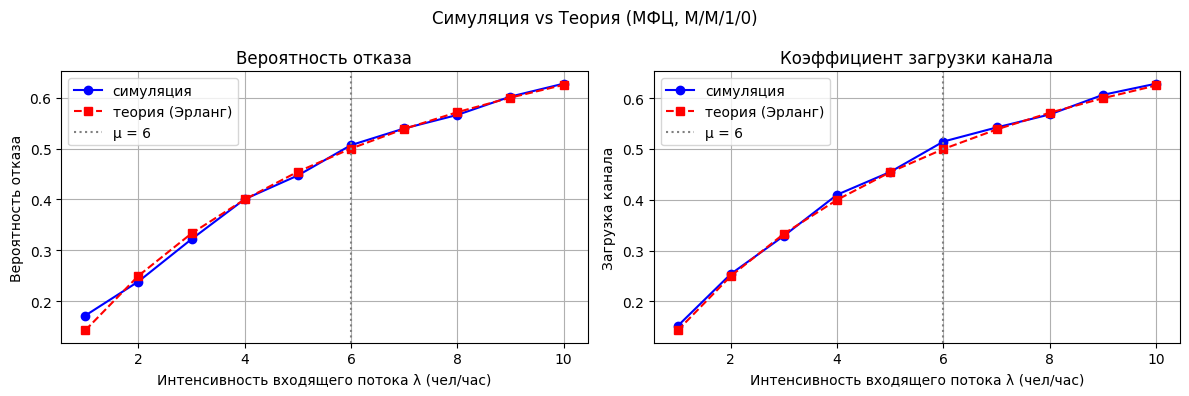

In [20]:
theory_rejection = []
theory_utilization = []

for arrival_rate in range(1, 11):
    t = theoretical(arrival_rate, SERVICE_RATE)
    theory_rejection.append(round(t["rejection_rate"], 4))
    theory_utilization.append(round(t["utilization"], 4))

df["доля отказов (теория)"]   = theory_rejection
df["загрузка канала (теория)"] = theory_utilization
df["погрешность отказов"]      = (df["доля отказов"] - df["доля отказов (теория)"]).abs().round(4)
df["погрешность загрузки"]     = (df["загрузка канала"] - df["загрузка канала (теория)"]).abs().round(4)
display(df)

plt.style.use("default")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df["интенсивность, λ (чел/час)"], df["доля отказов"],
         marker="o", color="blue", label="симуляция")
ax1.plot(df["интенсивность, λ (чел/час)"], df["доля отказов (теория)"],
         marker="s", color="red", linestyle="--", label="теория (Эрланг)")
ax1.axvline(x=SERVICE_RATE, color="gray", linestyle=":",
            label=f"μ = {SERVICE_RATE}")
ax1.set_title("Вероятность отказа")
ax1.set_xlabel("Интенсивность входящего потока λ (чел/час)")
ax1.set_ylabel("Вероятность отказа")
ax1.legend()
ax1.grid(True)

ax2.plot(df["интенсивность, λ (чел/час)"], df["загрузка канала"],
         marker="o", color="blue", label="симуляция")
ax2.plot(df["интенсивность, λ (чел/час)"], df["загрузка канала (теория)"],
         marker="s", color="red", linestyle="--", label="теория (Эрланг)")
ax2.axvline(x=SERVICE_RATE, color="gray", linestyle=":",
            label=f"μ = {SERVICE_RATE}")
ax2.set_title("Коэффициент загрузки канала")
ax2.set_xlabel("Интенсивность входящего потока λ (чел/час)")
ax2.set_ylabel("Загрузка канала")
ax2.legend()
ax2.grid(True)

plt.suptitle("Симуляция vs Теория (МФЦ, M/M/1/0)")
plt.tight_layout()
plt.show()